In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
url='https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df=pd.read_csv(url)

In [3]:
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [5]:
df['Month']=pd.to_datetime(df['Month'], format='%Y-%m')

In [ ]:
df.info()

In [7]:
# Se debe convertir el mes en el índice

df.set_index('Month', inplace=True)

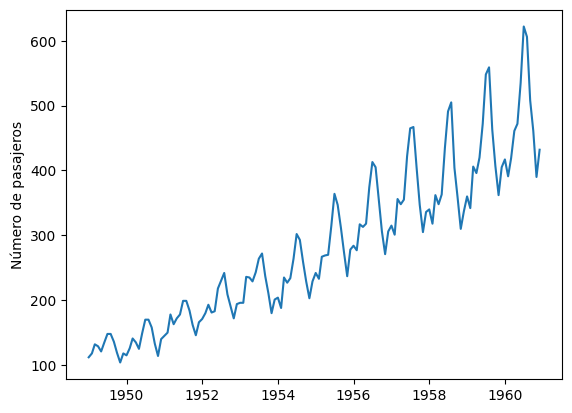

In [8]:
plt.plot(df)
plt.ylabel('Número de pasajeros')
plt.show()

In [9]:
media_anual = df.resample("YE").mean()
media_anual

,Passengers
Month,
1949-12-31,126.666667
1950-12-31,139.666667
1951-12-31,170.166667
1952-12-31,197.000000
1953-12-31,225.000000
1954-12-31,238.916667
1955-12-31,284.000000
1956-12-31,328.250000
1957-12-31,368.416667


In [10]:
media_anual.pct_change()

,Passengers
Month,
1949-12-31,NaN
1950-12-31,0.102632
1951-12-31,0.218377
1952-12-31,0.157689
1953-12-31,0.142132
1954-12-31,0.061852
1955-12-31,0.188699
1956-12-31,0.155810
1957-12-31,0.122366


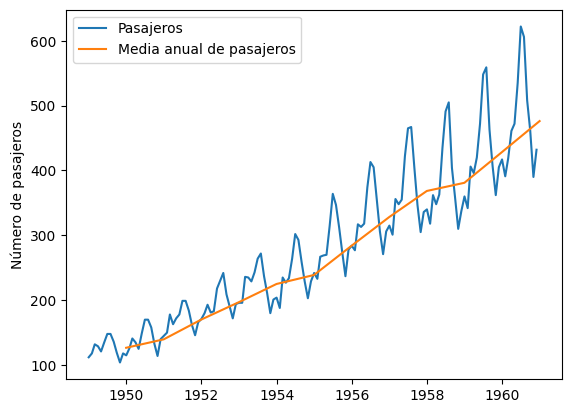

In [11]:
plt.plot(df, label='Pasajeros')
plt.plot(media_anual, label='Media anual de pasajeros')
plt.legend()
plt.ylabel('Número de pasajeros')
plt.show()

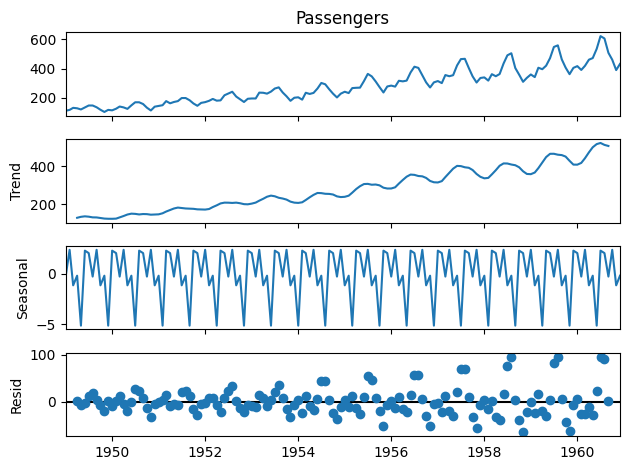

In [12]:
decompose= seasonal_decompose(df['Passengers'], model='additive', period=7)
decompose.plot()
plt.show()

In [13]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [14]:
def plot_lag_analysis(df, time_column, value_column, lags=5):
    """
    Genera gráficos de retardo para analizar la autocorrelación en una serie de tiempo.

    Args:
        df (pd.DataFrame): DataFrame con la serie de tiempo.
        time_column (str): Nombre de la columna con la información temporal.
        value_column (str): Nombre de la columna con los valores de la serie de tiempo.
        lags (int): Número máximo de retardos a visualizar.
    """
    df_lag = pd.DataFrame(df[value_column])
    plt.figure(figsize=(12, 6 * lags))
    plt.subplots_adjust(hspace=0.5)
    plt.suptitle(f'Gráficos de Retardo para {value_column}', y=1.02)

    for i in range(1, lags + 1):
        df_lag[f'Lag_{i}'] = df[value_column].shift(i)
        plt.subplot(lags, 2, 2 * i - 1)
        sns.scatterplot(x=value_column, y=f'Lag_{i}', data=df_lag)
        plt.title(f'Retardo {i} vs {value_column}')
        plt.xlabel(f'Valor en t')
        plt.ylabel(f'Valor en t-{i}')
        plt.grid(True)

        plt.subplot(lags, 2, 2 * i)
        sns.kdeplot(df_lag[value_column], label=f'Valor en t')
        sns.kdeplot(df_lag[f'Lag_{i}'], label=f'Valor en t-{i}')
        plt.title(f'Distribución de {value_column} vs Retardo {i}')
        plt.xlabel('Valor')
        plt.ylabel('Densidad')
        plt.legend()
        plt.grid(True)

    plt.show()



In [15]:
plot_lag_analysis(df, 'Month', 'Passengers', 25)